In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')
basepath = "/content/gdrive/My Drive/Colab Notebooks/"

In [ ]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import re
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import SGD, Adam, AdamW
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns


device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
df = pd.read_table(basepath + "fren/fra-eng/fra.txt", header=None)
df.columns = ["en", "fr"]
df.head()

,en,fr
0,Go.,Va !
1,Run!,Cours !
2,Run!,Courez !
3,Wow!,Ça alors !
4,Fire!,Au feu !


# Tokenization

In [ ]:
class Tokenizer:
  """Simple word splitting"""
  def __init__(self, corpus: str):
    tokens = self._getTokens(corpus)
    self.vocab = sorted(set(tokens))
    self.vocab.extend(["<UNK>"])
    self.vocab.insert(0, "<PAD>")
    self.strToId = {s : i for i,s in tqdm(enumerate(self.vocab))}
    self.idToStr = self.vocab

  def _getTokens(self, X):
    tokens = [w for w in re.split("[, ./]", re.sub("[()!\t]", "", X.lower())) if w]
    return tokens

  def tokenize(self, X):
    tokens = self._getTokens(X)
    tokens = [tk if tk in self.strToId else "<UNK>" for tk in tokens]
    return np.array([self.strToId[tk] for tk in tokens]), tokens

  def isInVocab(self, word):
    return word.lower() in self.vocab


In [ ]:
with open(basepath + "fren/fra-eng/fra.txt", "r") as f:
  corpus = f.read()
tk = Tokenizer(corpus)
print(f"\nVocab size: {len(tk.vocab)}")
tk.tokenize("what in the fighting spirit heheh va Bonjour")

58916it [00:00, 5080733.07it/s]


Vocab size: 58916


(array([56918, 26564, 52261, 21533, 58915, 58915, 55198,  7956]),
 ['what', 'in', 'the', 'fighting', '<UNK>', '<UNK>', 'va', 'bonjour'])

# Embedder

In [ ]:
class Embedder(nn.Module):
  """Implements CBOW Word2Vec. Note that softmax is not applied as we are using CELoss which applies softmax internally"""
  def __init__(self, vocabSize: int, embeddingDim: int):
    super().__init__()
    self.embeddings = nn.Embedding(vocabSize, embeddingDim, padding_idx=0)
    self.model = nn.Sequential(
        nn.Linear(embeddingDim, vocabSize),
        nn.SiLU(),
        nn.Linear(64, 128),
        nn.SiLU(),
        nn.Linear(128, vocabSize)
    )

  def forward(self, X):
    embed = torch.mean(self.embeddings(X), dim=1)
    pred = self.model(embed)
    return pred

  def embed(self, X):
    return self.embeddings(X)


In [ ]:
def getTrainingExamples(phrase, tokenizer: Tokenizer, windowSize: int=2):
  """Note: true window size is 2 * windowSize argument, windowSize argument specifies how many tokens on each side."""
  tokens, _ = tokenizer.tokenize(phrase)
  y = []
  x = []
  for i in range(len(tokens)):
    y.append(tokens[i])
    x.append([tokens[j] for j in range(max(i - windowSize, 0), i)] + [tokens[j] for j in range(i + 1, min(len(tokens), i + windowSize + 1))])

  return x, y



In [ ]:
getTrainingExamples("hello world i love fighting monkeys", tk)

([[np.int64(57337), np.int64(26064)],
  [np.int64(25014), np.int64(26064), np.int64(31550)],
  [np.int64(25014), np.int64(57337), np.int64(31550), np.int64(21533)],
  [np.int64(57337), np.int64(26064), np.int64(21533), np.int64(34417)],
  [np.int64(26064), np.int64(31550), np.int64(34417)],
  [np.int64(31550), np.int64(21533)]],
 [np.int64(25014),
  np.int64(57337),
  np.int64(26064),
  np.int64(31550),
  np.int64(21533),
  np.int64(34417)])

In [ ]:
trainingExamples = df.en.apply(getTrainingExamples, args=[tk])

In [ ]:
processedExamples = pd.concat([pd.DataFrame(trainingExamples.tolist()).iloc[:, 0].explode(), pd.DataFrame(trainingExamples.tolist()).iloc[:, 1].explode()], axis=1)

In [ ]:
processedExamples.columns = ["X", "y"]
processedExamples.X = processedExamples.X.apply(np.array)

processedExamples = processedExamples.loc[processedExamples.X.apply(len) != 0]
processedExamples.X = processedExamples.X.apply(lambda x: np.concat([x, np.zeros(4 - len(x))])) # Padding

X = torch.tensor(np.vstack(processedExamples.X.to_numpy()), device=device, dtype=torch.int64)
y = torch.tensor(np.vstack(processedExamples.y.to_numpy()), device=device, dtype=torch.int64)


In [ ]:
class EmbedderDataset(Dataset):
  def __init__(self, X, y):
    self.X = X
    self.y = y.flatten()

  def __len__(self):
    return len(self.y)

  def __getitem__(self, idx):
    return X[idx], y[idx]

trainloader = DataLoader(EmbedderDataset(X, y), batch_size=4096, shuffle=True)

embedder = Embedder(len(tk.vocab), 512).to(device)

In [ ]:
lr = 5e-3
optim = AdamW(embedder.parameters(), lr=lr, weight_decay=1e-4) #, lr=lr, momentum=0.9)
lossFn = nn.CrossEntropyLoss()

for epoch in tqdm(range(50)):
  cumLoss = 0
  for idx, (features, target) in enumerate(trainloader):
    y_pred = embedder(features)
    loss = lossFn(y_pred, target.flatten())
    optim.zero_grad()
    loss.backward()
    optim.step()
    cumLoss += loss

  print(f"{epoch=} | Average loss: {cumLoss / len(trainloader)}")

  2%|▋                                    | 1/50 [00:21<17:29, 21.41s/it]

epoch=0 | Average loss: 5.17897891998291


  4%|█▍                                   | 2/50 [00:42<17:06, 21.38s/it]

epoch=1 | Average loss: 3.7288832664489746


  6%|██▏                                  | 3/50 [01:04<16:44, 21.38s/it]

...

epoch=47 | Average loss: 2.412325620651245


 98%|███████████████████████████████████▎| 49/50 [17:33<00:21, 21.60s/it]

epoch=48 | Average loss: 2.411499500274658


100%|████████████████████████████████████| 50/50 [17:54<00:00, 21.50s/it]

epoch=49 | Average loss: 2.4105401039123535


In [ ]:
tk.isInVocab("attention")

[0.13914856 0.12130482]


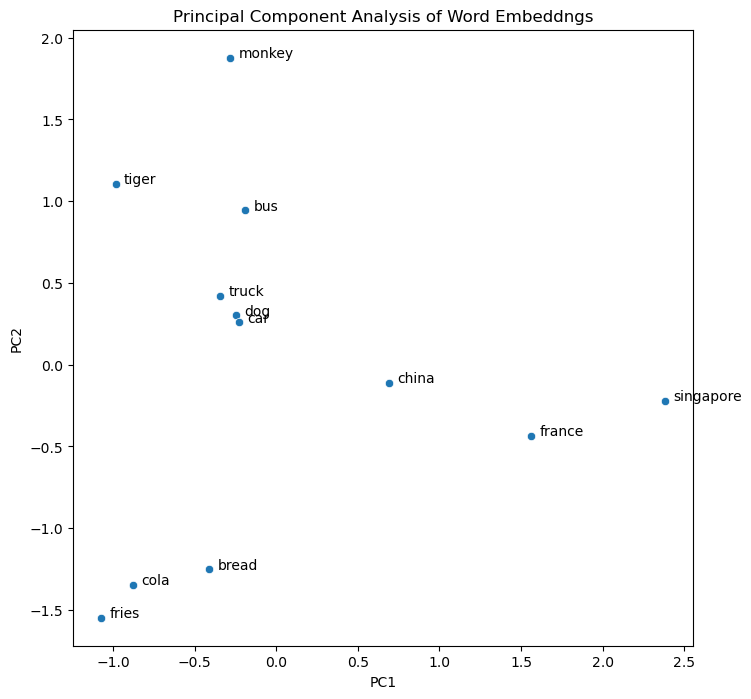

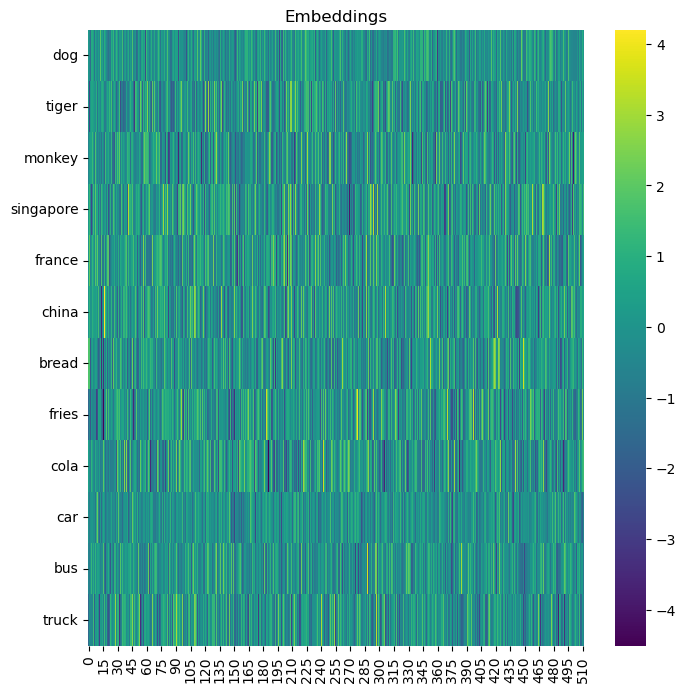

In [ ]:
#text = "eagle parrot bird lion hammer wrench screw car boat ship water sea human carrot potato lettuce king queen man woman"
#text = "tiger lion singapore malaysia acid base chemical"
#text = "dog horse hammer wrench screwdriver apple banana orange monkey china singapore france"
text = "dog tiger monkey singapore france china bread fries cola car bus truck"
#text = "man woman child car bus truck singapore china america person van india"
tokens, _ = tk.tokenize(text)
tokens = torch.tensor(tokens, device=device)

with torch.no_grad():
  embeddings = embedder.embed(tokens).detach().cpu()


pca = PCA(n_components=2, svd_solver="full")
scaler = StandardScaler()
pc = pca.fit_transform(embeddings)
pc = scaler.fit_transform(pc)
print(pca.explained_variance_ratio_)


pc = pd.concat([pd.DataFrame(text.split(" ")), pd.DataFrame(pc)], axis=1)

pc.columns = ["word", "PC1", "PC2"]

plt.figure(figsize=(8, 8))
sns.scatterplot(pc, x="PC1", y="PC2")
plt.title("Principal Component Analysis of Word Embeddngs")

def labelPoint(row, deltaX=0.05, deltaY=0):
  plt.text(row.PC1 + deltaX, row.PC2 + deltaY, row.word)

pc.apply(labelPoint, axis=1)

plt.show()

embeddings = pd.DataFrame(embeddings)
embeddings.index = text.split(" ")

plt.figure(figsize=(8, 8))
plt.title("Embeddings")
sns.heatmap(embeddings, cmap="viridis")
plt.show()


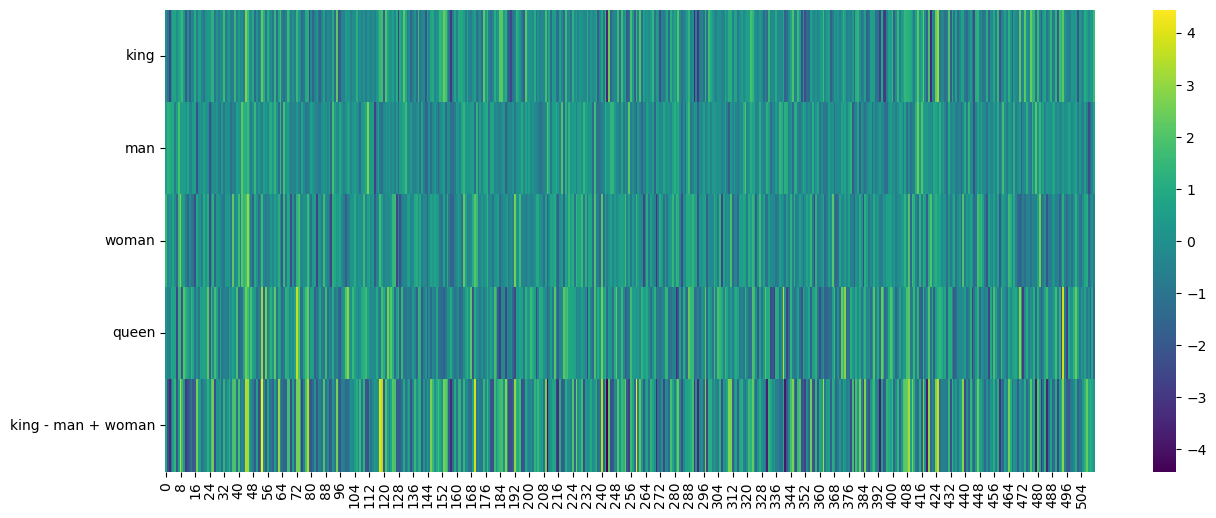

In [ ]:
text = "king man woman queen"
tokens, _ = tk.tokenize(text)
tokens = torch.tensor(tokens, device=device)

with torch.no_grad():
  embeddings = embedder.embed(tokens).detach().cpu()

embeddings = pd.DataFrame(embeddings)
embeddings.index = text.split(" ")

pseudoQueen =  embeddings.loc["king"] - embeddings.loc["man"] + embeddings.loc["woman"]

embeddings = pd.concat([embeddings, pd.DataFrame(pseudoQueen).T], axis=0)
embeddings.index = text.split(" ") + ["king - man + woman"]
embeddings

plt.figure(figsize=(15, 6))
sns.heatmap(embeddings, cmap="viridis")
plt.show()


In [ ]:
#torch.save(embedder.state_dict(), basepath + "fren/fren_embedderModelParams_15Feb0107.pt")